# Linear Regression

## Simple Linear Regression
We want to predict a continuous value y (Dependent Variable) based on a single input x (Independent Variable).

**For example, Predicting Salary (y) based on Years of Experience (x)**
> Imagine a scatter plot of dots. **Linear Regression** tries to draw a straight line through the data points that sits as close to all of them as possible.

The equation for that line is: `y = mx + b`
Where,
- y = The predicted value
- m = Coefficient or Slope (How much y changes for every 1 unit change in x)
- x = Input feature
- b = The value of y when x is 0

**How do we know if a line is "best"?** 
We look at the error. For every data point the error will be: $y_{\text{actual}}$ - $y_{\text{predicted}}$

We want to minimize the total error. For this We define a cost function.

> To find the perfect b and m without guessing, we use **Ordinary Least Squares (OLS)**.
> To check how well the model's line fits the actual data, we calculate **R-squared**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class SimpleLinearRegression:
    def __init__(self):
        self.slope = None
        self.intercept = None

    def fit(self, X, y):
        x_mean = np.mean(X)
        y_mean = np.mean(y)

        numerator = np.sum((X - x_mean) * (y - y_mean))
        denominator = np.sum((X - x_mean) ** 2)

        # Calculate Coefficient or Slope
        self.slope = numerator / denominator
        
        # Calculate Intercept
        self.intercept = y_mean - (self.slope * x_mean)

        print(f"Model Trained: Slope: {self.slope:.4f}, Intercept: {self.intercept:.4f}")

    def predict(self, X):
        return self.slope * X + self.intercept

    def r2_score(self, y_actual, y_predicted):
        y_mean = np.mean(y_actual)
        ss_residuals = np.sum((y_actual - y_predicted) ** 2)
        ss_total = np.sum((y_actual - y_mean) ** 2)
        return f"R2 Score: {(1 - (ss_residuals / ss_total)):.2f}"

Model Trained: Slope: 30212.1212, Intercept: -18666.6667
R2 Score: 0.96


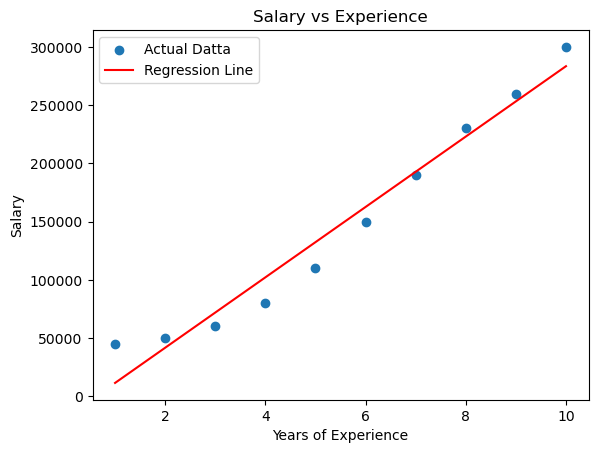

In [3]:
# Create a dummy dataset (Experience vs Salary)
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]) # Years of Experience
y = np.array([45000, 50000, 60000, 80000, 110000, 150000, 190000, 230000, 260000, 300000]) # Sarary

# Train our Model 
model = SimpleLinearRegression()
model.fit(X, y)

# Predict
y_pred = model.predict(X)

# Performance Metrics
r2 = model.r2_score(y, y_pred)
print(r2)

# Visualize
plt.scatter(X, y, label='Actual Datta')
plt.plot(X, y_pred, color='red', label='Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience')
plt.legend()
plt.show()